In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
rfm = pd.read_csv("data/rfm_features.csv")


In [3]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [4]:
x = rfm[["Recency","Frequency","Monetary"]]

In [5]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
inertia = []
silhouette_scores = []

k_range = range(2,9)
for i in k_range:
    kmeans = KMeans(n_clusters=i, n_init=10, random_state= 42)
    labels = kmeans.fit_predict(x_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_scaled,labels))


In [8]:
import matplotlib.pyplot as plt

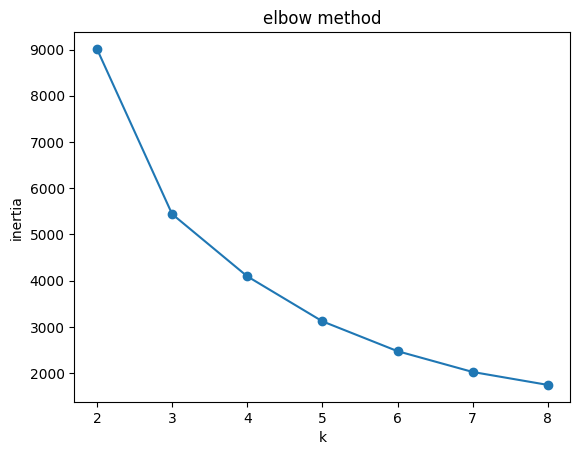

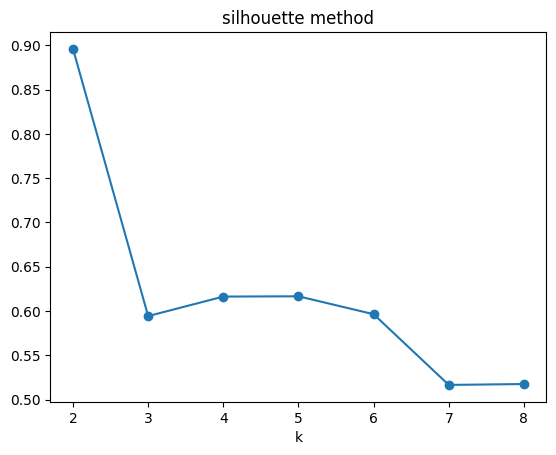

In [9]:
plt.figure()
plt.plot(k_range,inertia, marker = "o")
plt.title("elbow method")
plt.xlabel("k")
plt.ylabel("inertia")

plt.figure()
plt.plot(k_range, silhouette_scores, marker = "o")
plt.xlabel("k")
plt.title("silhouette method")

plt.show()

In [10]:
# so k is 5

In [11]:
k =5
kmeans_model = KMeans(n_clusters=k,n_init=10, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(x_scaled)

In [12]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,0
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,1
3,12349.0,19,1,1757.55,1
4,12350.0,310,1,334.40,3


# interpreting the clusters

In [13]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency" : "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID":"count"
})

In [14]:
cluster_summary.head(2)

,Recency,Frequency,Monetary,CustomerID
Cluster,,,,
0,34.153846,34.000000,73826.107692,13
1,35.370070,3.436968,1258.882314,2586


In [15]:
cluster_summary = cluster_summary.rename(columns={"CustomerID":"count"})

In [16]:
cluster_summary

,Recency,Frequency,Monetary,count
Cluster,,,,
0,34.153846,34.000000,73826.107692,13
1,35.370070,3.436968,1258.882314,2586
2,3.000000,45.250000,225721.652500,4
3,294.256410,1.302885,476.810192,624
4,15.656250,16.728125,7576.232344,320
5,1.000000,205.000000,88772.395000,2
6,4.363636,73.636364,31767.364545,11
7,155.300771,2.101542,699.746171,778


Now we have got the overall idea about the customers and their segments.  
We are going to tag the clusters. So that personalized attention can be given

cluster 4 -> vip list, cluster 3 -> Frequent safe customers, cluster 1 -> one time customers, cluster 0 -> at risk customers, 2 - growth potential

In [17]:
# cluster_summary = cluster_summary.reset_index()
segment_map = {
    0: "Risk Customers",
    1: "One time customers",
    2: "growth potential",
    3: "Frequent safe customers",
    4: "Vip list"
}
rfm["Tags"] = rfm["Cluster"].map(segment_map)

In [18]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Tags
0,12346.0,326,1,77183.60,0,Risk Customers
1,12347.0,2,7,4310.00,1,One time customers
2,12348.0,75,4,1797.24,1,One time customers
3,12349.0,19,1,1757.55,1,One time customers
4,12350.0,310,1,334.40,3,Frequent safe customers


## visualizing the x_scaled.. for understanding

In [19]:
from sklearn.decomposition import PCA

In [20]:
pca = PCA(n_components=2)

In [21]:
x_pca = pca.fit_transform(x_scaled)

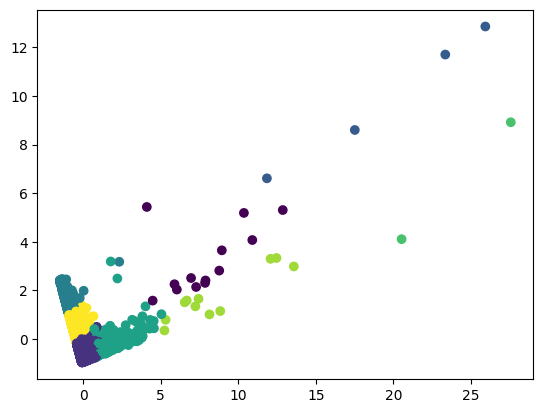

Text(0, 0.5, 'PC2')

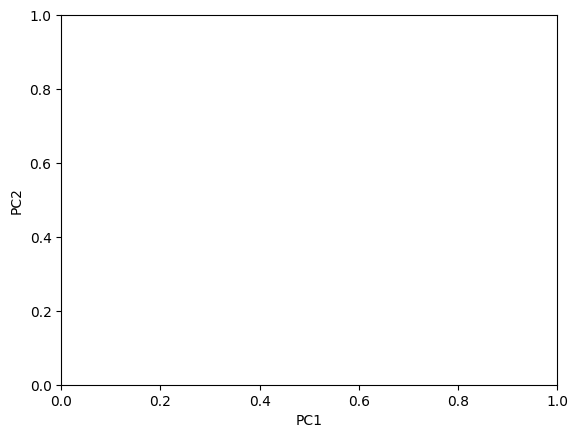

In [22]:
plt.figure()
plt.scatter(x_pca[:,0],x_pca[:,1],c = rfm["Cluster"])
plt.show()
plt.xlabel("PC1")
plt.ylabel("PC2")

In [23]:
# saving the artifacts

In [24]:
import joblib

In [33]:
joblib.dump(kmeans_model,"models/kmeans_model.joblib")

['models/kmeans_model.joblib']

In [34]:
joblib.dump(scaler,"models/rfm_scaler.joblib")

['models/rfm_scaler.joblib']

In [31]:
rfm["CustomerID"] = rfm["CustomerID"].astype(int)

In [32]:
# joblib.dump("rfm","data/rfm_with_cluster.csv")
rfm.to_csv("data/rfm_with_cluster.csv",index=False)